importation des bibliotech 

le chargement de data en fromat de csv

In [295]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np 
from sklearn.model_selection import train_test_split


In [296]:
df = pd.read_csv("../data/row/car-price.csv")

print(df.head())
print("=======================================")
print(df.shape)

                        name    year  selling_price  km_driven    fuel  \
0              Maruti 800 AC  2007.0          60000    70000.0  Petrol   
1       Hyundai Verna 1.6 SX  2012.0         600000   100000.0  Diesel   
2     Datsun RediGO T Option  2017.0         250000    46000.0  Petrol   
3       Maruti Alto LX BSIII  2007.0         140000   125000.0  Petrol   
4  Hyundai Xcent 1.2 Kappa S  2016.0         550000    25000.0  Petrol   

  seller_type transmission        owner  
0  Individual       Manual  First Owner  
1  Individual       Manual  First Owner  
2  Individual       Manual  First Owner  
3  Individual       Manual  First Owner  
4  Individual       Manual  First Owner  
(4340, 8)


les info sur les donnes ariver dans csv

In [297]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           4340 non-null   object 
 1   year           4297 non-null   float64
 2   selling_price  4340 non-null   int64  
 3   km_driven      4167 non-null   float64
 4   fuel           4254 non-null   object 
 5   seller_type    4275 non-null   object 
 6   transmission   4340 non-null   object 
 7   owner          4254 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 271.4+ KB
None


les columns quand a dans la dataframe 

In [298]:
print(df.columns)

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='object')


Analyse statistique avec describe

In [299]:
print(df.describe())

              year  selling_price      km_driven
count  4297.000000   4.340000e+03    4167.000000
mean   2013.087736   5.041273e+05   66237.198224
std       4.219918   5.785487e+05   46635.456187
min    1992.000000   2.000000e+04       1.000000
25%    2011.000000   2.087498e+05   35000.000000
50%    2014.000000   3.500000e+05   60000.000000
75%    2016.000000   6.000000e+05   90000.000000
max    2020.000000   8.900000e+06  806599.000000


definir la valeur qui doit predict le model 

In [300]:
input_data = df.drop("selling_price",axis=1)
output_data = df["selling_price"]


In [301]:
df["fuel"].value_counts()

fuel
Diesel      2116
Petrol      2077
CNG           38
LPG           22
Electric       1
Name: count, dtype: int64

In [302]:
df["seller_type"].value_counts()

seller_type
Individual          3198
Dealer               976
Trustmark Dealer     101
Name: count, dtype: int64

In [303]:
df["transmission"].value_counts()

transmission
Manual       3892
Automatic     448
Name: count, dtype: int64

In [304]:
df["owner"].value_counts()

owner
First Owner             2771
Second Owner            1084
Third Owner              302
Fourth & Above Owner      80
Test Drive Car            17
Name: count, dtype: int64

In [305]:
df.isnull().sum()

name               0
year              43
selling_price      0
km_driven        173
fuel              86
seller_type       65
transmission       0
owner             86
dtype: int64

In [306]:
df["km_driven"] = df["km_driven"].fillna(
    df["km_driven"].median()
)

df["year"] = df["year"].fillna(
    df["year"].median()
)

df["fuel"] = df["fuel"].fillna(
    df["fuel"].mode()[0]
)
df["seller_type"] = df["seller_type"].fillna(
    df["seller_type"].mode()[0]
)
df["owner"] = df["owner"].fillna(
    df["owner"].mode()[0]
)



In [307]:
# df.duplicated().sum()

df = df.drop_duplicates()
df.shape



(3672, 8)

outlier de kilometrage 


In [308]:
Q1_km = df["km_driven"].quantile(0.25)
Q3_km = df["km_driven"].quantile(0.75)

demi = Q3_km - Q1_km

upper = Q3_km +1.5* demi

out = df[
    (df["km_driven"] > upper)
]


In [309]:

ref = df["year"].max()

df["age"] = ref - df["year"]

In [310]:
df["km_per_year"] = np.where(
    df["age"] >0,
    df["km_driven"] / df["age"],
    np.nan
)

Q1_kk = df["km_per_year"].quantile(0.25)
Q3_kk = df["km_per_year"].quantile(0.75)

demii = Q3_kk - Q1_kk

upper = Q3_kk + 1.5 * demii

outliers = df[
    (df["km_per_year"] > upper)
]


In [311]:

# print(outliers)

delete = df[
    (df["age"] > 0) &
    (df["km_per_year"] > 70000)
]

df.loc[delete.index,"year"] = (
    (2020 - df.loc[delete.index,"km_driven"] // 70000)
)
print(delete)


                                    name    year  selling_price  km_driven  \
331    Maruti SX4 S Cross DDiS 320 Delta  2016.0         665000   560000.0   
1283    Maruti Alto 800 CNG LXI Optional  2019.0         300000   120000.0   
1950            Hyundai Xcent 1.2 VTVT S  2019.0         600000    80000.0   
2218  Skoda Laura Elegance 2.0 TDI CR AT  2019.0         475000   105000.0   
2279    Hyundai Verna CRDi 1.6 SX Option  2019.0        1100000   100000.0   
3183              Maruti Swift Dzire ZDI  2019.0         475000   120000.0   
4278              Maruti Swift VXI BSIII  2009.0         250000   806599.0   

        fuel seller_type transmission         owner   age    km_per_year  
331   Diesel      Dealer       Manual   First Owner   4.0  140000.000000  
1283     CNG  Individual       Manual   First Owner   1.0  120000.000000  
1950  Petrol  Individual       Manual   First Owner   1.0   80000.000000  
2218  Diesel      Dealer    Automatic   First Owner   1.0  105000.000000  


In [312]:
delete.to_csv("../data/test/km_outlier.csv")

# df = df.drop(delete.index)


outlier de prix


In [313]:
# Q1_price = df["year"].quantile(0.25)
# Q3_price = df["year"].quantile(0.75)

# demi_3 = Q3_price - Q1_price

# upper_3 = Q3_price + demi_3
# lower_3 = Q1_price - demi_3


# out_3 = df[
#     (df["year"] < lower_3) |
#     (df["year"] > upper_3)
# ]

# df = df.drop(out_3)

print(df)   

                                    name    year  selling_price  km_driven  \
0                          Maruti 800 AC  2007.0          60000    70000.0   
1                   Hyundai Verna 1.6 SX  2012.0         600000   100000.0   
2                 Datsun RediGO T Option  2017.0         250000    46000.0   
3                   Maruti Alto LX BSIII  2007.0         140000   125000.0   
4              Hyundai Xcent 1.2 Kappa S  2016.0         550000    25000.0   
...                                  ...     ...            ...        ...   
4335    Maruti S-Cross Alpha DDiS 200 SH  2018.0         950000    30000.0   
4336                Renault KWID 1.0 RXL  2018.0         300000    50852.0   
4337  Chevrolet Tavera Neo 3 9 Str BSIII  2016.0         500000   120000.0   
4338         Tata Sumo GX TC 7 Str BSIII  2006.0         115999   100000.0   
4339                     Maruti Ritz VDi  2012.0         225000    90000.0   

        fuel seller_type transmission        owner   age   km_p

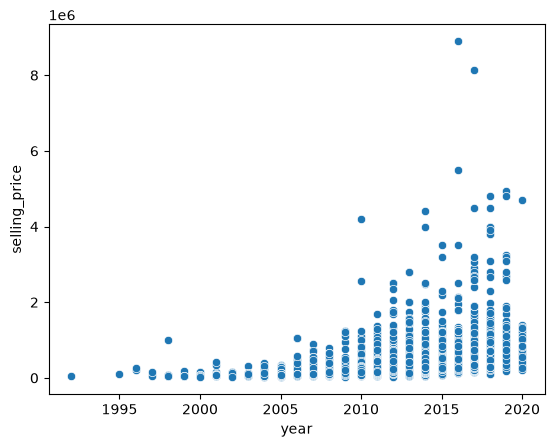

In [314]:
sns.scatterplot(
    data=df,
    x="year",
    y="selling_price"
)

plt.show()

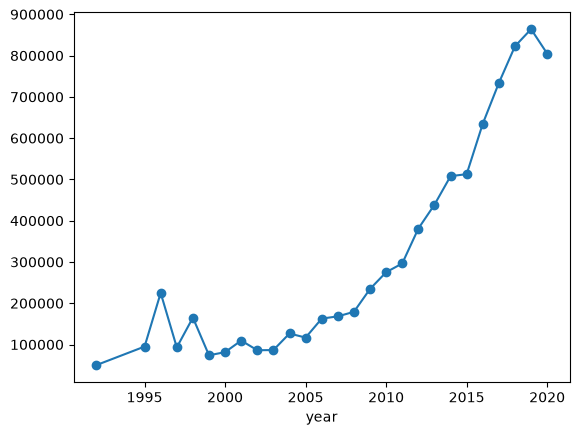

In [315]:
df.groupby("year")["selling_price"].mean().plot(
    kind="line",
    marker="o"
)

plt.show()

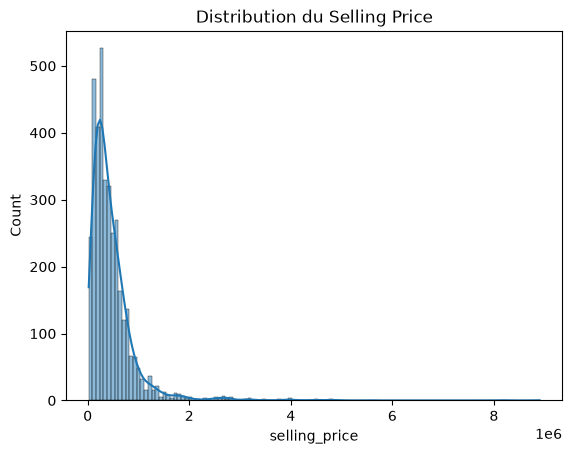

In [316]:
sns.histplot(df["selling_price"], kde=True)
plt.title("Distribution du Selling Price")
plt.show()

In [317]:
Q1_price = df["selling_price"].quantile(0.25)
Q3_price = df["selling_price"].quantile(0.75)

IQR_price = Q3_price - Q1_price

lower_price = Q1_price - 1.5 * IQR_price
upper_price = Q3_price + 1.5 * IQR_price

out_price = df[
    (df["selling_price"] < lower_price) |
    (df["selling_price"] > upper_price)
]

out_price[
    ["name", "year", "selling_price", "km_driven",
     "fuel", "transmission"]
]

out_price["selling_price"].describe()

count    1.740000e+02
mean     2.123690e+06
std      1.154848e+06
min      1.225000e+06
25%      1.376250e+06
50%      1.700000e+06
75%      2.568750e+06
max      8.900000e+06
Name: selling_price, dtype: float64

### Justification du traitement des outliers

Les valeurs aberrantes du `km_driven` ont été traitées afin de limiter leur influence sur le modèle.

Pour les véhicules ayant un `km_per_year > 100 000`, l’âge a été recalculé à partir du kilométrage afin de conserver les observations tout en améliorant la cohérence des données.

Aucun outlier n’a été supprimé dans `year`, car une année ancienne peut correspondre à un véhicule réel, par exemple une voiture de 1995 toujours proposée à la vente.

#### Traitement des outliers du prix
`selling_price` représente la variable cible du modèle. Une valeur élevée ne signifie pas nécessairement qu'elle est incorrecte : elle peut correspondre à un véhicule récent, peu kilométré ou ayant plusieurs caractéristiques justifiant un prix élevé.

In [ ]:
df = pd.get_dummies(
    df,
    columns=["fuel", "seller_type", "transmission","owner"]
)

# print(df)

                                    name    year  selling_price  km_driven  \
0                          Maruti 800 AC  2007.0          60000    70000.0   
1                   Hyundai Verna 1.6 SX  2012.0         600000   100000.0   
2                 Datsun RediGO T Option  2017.0         250000    46000.0   
3                   Maruti Alto LX BSIII  2007.0         140000   125000.0   
4              Hyundai Xcent 1.2 Kappa S  2016.0         550000    25000.0   
...                                  ...     ...            ...        ...   
4335    Maruti S-Cross Alpha DDiS 200 SH  2018.0         950000    30000.0   
4336                Renault KWID 1.0 RXL  2018.0         300000    50852.0   
4337  Chevrolet Tavera Neo 3 9 Str BSIII  2016.0         500000   120000.0   
4338         Tata Sumo GX TC 7 Str BSIII  2006.0         115999   100000.0   
4339                     Maruti Ritz VDi  2012.0         225000    90000.0   

       age   km_per_year  fuel_CNG  fuel_Diesel  fuel_Electric 

### Definir les valeur de entrainment et valuer de test 

In [ ]:
input = df.drop("selling_price",axis=1)
output = df["selling_price"]

X_train, X_test, y_train, y_test = train_test_split(
    input,output,test_size=0.2,random_state=42
)


In [319]:
final_df = df.drop(["age","km_per_year"],axis=1)

final_df.to_csv("../data/processed/clean_data.csv")